### Lab 3 Report: Clustering, Association Rules, and Recommenders
**Name:** Chloe Barker  
**Course:** DS 7331  
**Environment:** Python 3.11, NumPy, pandas, scikit-learn, seaborn, matplotlib, mlxtend  

---
### **Data Cards & Ethics Notes**
#### Clustering Dataset: Health & Lifestyle (Kaggle)
- License: CC0 Public Domain  
- Shape: 100,000 rows × 16 columns  
- Label (used only for evaluation): `disease_risk`

| Variable Name | Type | Description | Expected Domain |
|---|---|---|---|
| id | Numeric | Unique identifier for each participant | Positive integers |
| age | Numeric | Age of the individual (years) | 18-90+ |
| gender | Categorical | Gender identity | {Male, Female} |
| bmi | Numeric | Body Mass Index (kg/m²) | ~15-45 |
| daily_steps | Numeric | Number of steps taken per day | ≥ 0 |
| sleep_hours | Numeric | Hours of sleep per night | 0-12 |
| water_intake_l | Numeric | Daily water intake (liters) | ≥ 0 |
| calories_consumed | Numeric | Estimated daily calories consumed (kcal/day) | ≥ 0 |
| smoker | Categorical | Smoking status | {0 = No, 1 = Yes} |
| alcohol | Categorical | Alcohol consumption status | {0 = No, 1 = Yes} |
| resting_hr | Numeric | Resting heart rate (beats per minute) | ≥ 0 (typical adult range ~40–120) |
| systolic_bp | Numeric | Systolic blood pressure (mmHg) | ≥ 0 |
| diastolic_bp | Numeric | Diastolic blood pressure (mmHg) | ≥ 0 |
| cholesterol | Numeric | Total cholesterol (mg/dL) | ≥ 0 |
| family_history | Categorical | Family history of disease | {0 = No, 1 = Yes} |
| disease_risk | Target (Categorical) | Overall disease risk classification | {0 = Low Risk, 1 = High Risk} | 
- Ethical considerations:  
  - Fully synthetic; no real health insights should be inferred  
  - Relationships reflect generator assumptions, not real behaviors  
  - Safe for algorithm testing but not suitable for medical interpretation
---
#### Transactional Dataset: Online Retail (UCI)
- License: CC BY 4.0  
- Shape: 541,909 transactions × 8 columns 
- ~4,372 customers, ~4,070 items

| Variable Name | Role | Type | Description |
|---|---|---|---|
| InvoiceNo | ID | Categorical | Invoice number; 6-digit code per transaction. If it starts with letter 'C', the invoice is a cancellation. |
| StockCode | Item ID | Categorical | Product code uniquely assigned to each distinct product |
| Description | Feature | Categorical | Product name / description |
| Quantity | Feature | Integer | Number of units purchased per transaction |
| InvoiceDate | Feature | Date/Time | Timestamp of transaction |
| UnitPrice | Feature | Continuous | Product price per unit (£)| 
| CustomerID | User ID | Categorical | 5-digit unique customer identifier |
| Country | Feature | Categorical | Customer’s country of residence |  

- Ethical considerations:  
  - Some missing IDs limit user-level completeness
  - Data collected from a single retailer; not generalizable  
  - Potential mix of wholesale + retail behaviors  
---

### **Exploratory Data Analysis**

#### Clustering Dataset
- Numeric features show skewed but smooth distributions.  
- Categorical variables are moderately imbalanced but usable.  
- Pairwise plots show only slight separation for `disease_risk`.  
- **Correlation heatmap:** correlations nearly zero (+/- 0.006), indicating synthetic independence.  
- **Implication:** Very weak natural cluster structure; variables operate on different scales → scaling required.

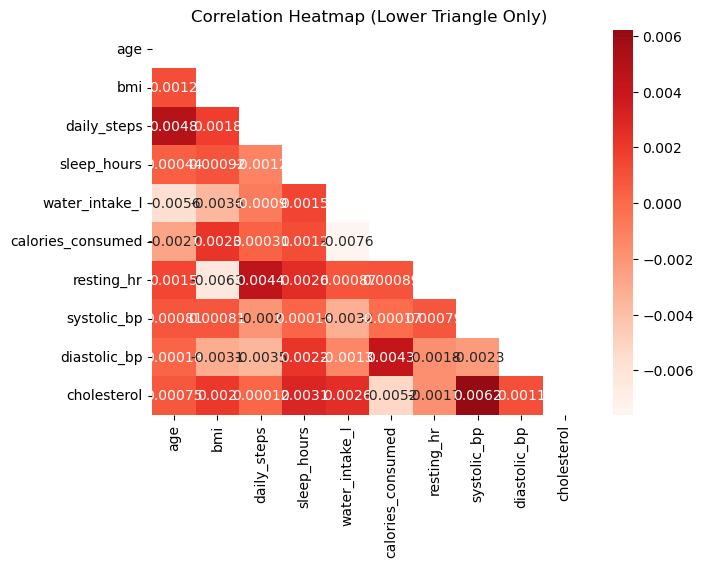

In [1]:
import sys, platform, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version

clustering_df = pd.read_csv("/Users/chloebarker/Downloads/Artificial_Intelligence/Labs/Lab-3/health_lifestyle_dataset.csv")
id_col = ['id']
cat_cols = ['gender', 'smoker', 'alcohol', 'family_history']
numeric_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l','calories_consumed', 'resting_hr', 'systolic_bp','diastolic_bp', 'cholesterol']
label_col = 'disease_risk'

corr = clustering_df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='Reds', center=0)
plt.title("Correlation Heatmap (Lower Triangle Only)")
plt.show()

#### Transactional Dataset
- **Item popularity:** heavily skewed; few items dominate sales.  
- **User activity:** long-tailed; minority of high-activity customers.  
- **Co-occurrence:** top-selling items frequently appear in the same carts.  
- **Implication:** Strong candidate for association rule mining and item-item recommendations.

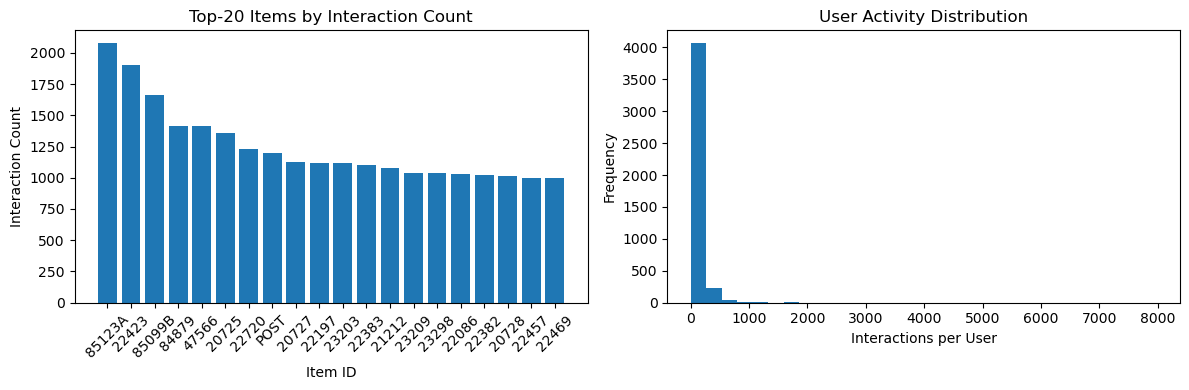

In [2]:
interactions_df = pd.read_csv("/Users/chloebarker/Downloads/Artificial_Intelligence/Labs/Lab-3/Online_Retail.csv")
interactions_df = interactions_df.dropna(subset=["CustomerID", "StockCode"]).copy()
interactions_df = interactions_df.rename(columns={
    "CustomerID": "user_id",
    "StockCode": "item_id",
    "InvoiceNo": "invoice_id"})

import matplotlib.pyplot as plt

item_counts = interactions_df["item_id"].value_counts()
user_counts = interactions_df["user_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left plot: Top items ---
axes[0].bar(item_counts.head(20).index, item_counts.head(20).values)
axes[0].set_title("Top-20 Items by Interaction Count")
axes[0].set_xlabel("Item ID")
axes[0].set_ylabel("Interaction Count")
axes[0].tick_params(axis='x', rotation=45)

# --- Right plot: User activity distribution ---
axes[1].hist(user_counts, bins=30)
axes[1].set_title("User Activity Distribution")
axes[1].set_xlabel("Interactions per User")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### **Preprocessing Pipeline for Clustering**
Raw Data → Drop missing values → OneHotEncoder for categoricals → StandardScaler for numerics → Concatenate → PCA for visualization → Compute distance matrices

### **Clustering Methods and Evaluation**

All clustering models were trained on the standardized/scaled, one-hot encoded feature matrix X_processed. The disease_risk label was never used to train models; it was used only for external evaluation via ARI and NMI. Models were evaluated for k = 2–8 (or equivalent parameters) using:

- Internal metrics: Silhouette, Davies–Bouldin, Calinski–Harabasz  
- External metrics: Adjusted Rand Index (ARI), Normalized Mutual Information (NMI)  
- Visualization: PCA (first two components =18% variance explained)

Across all methods, internal metrics are low and external metrics remain near zero, indicating weak cluster structure.

#### K-means
K-means was run for k = 2–8.
  
- Silhouette, Calinski–Harabasz, and Davies–Bouldin consistently favor k = 2, although absolute values remain weak.  
- PCA projections show completely overlapping clusters.  
- ARI and NMI remain 0, meaning K-means does not recover disease_risk structure.  
Interpretation: If any segmentation exists, it is limited to a very weak 2-cluster partition.

#### Hierarchical Agglomerative Clustering (HAC)
Two linkages were evaluated: Ward and Average. Dendrograms (300-point subsample) were used for structural interpretation.

- Both linkages show silhouette peaks at k = 2 and drift toward zero or negative values as k increases.  
- Dendrograms lack large linkage jumps, suggesting no natural clusters.  
- ARI and NMI remain near zero.  
Interpretation: HAC confirms K-means results — the dataset is weakly clusterable with no clear multicluster structure.

#### Gaussian Mixture Models (GMM) 
GMMs with 2–8 components and full covariance were evaluated.

- Silhouette remains small and best at k = 2, confirming overlapping clusters.  
- Davies–Bouldin and Calinski–Harabasz show no strong preference for higher k.  
- BIC may prefer more components, reflecting density approximation rather than discrete clusters.  
- ARI and NMI remain near zero, so even multiple Gaussian components do not recover disease_risk.  
Interpretation: GMMs support the conclusion that clusters are highly overlapping and weakly separable.

#### DBSCAN  
Explored eps in {0.5, 1.0, 1.5, 2.0, 3.0, 4.0} and min_samples in {3, 5, 10} on a 2,000-point subset.

- Most settings yield one large cluster or mostly noise.  
- A high silhouette (~0.56) at eps = 1.5, min_samples = 3 results from tiny core clusters and nearly all points labeled as noise, making the metric meaningless.  
Interpretation: The dataset lacks density-based structure; DBSCAN is not suitable for this problem.

#### Spectral Clustering  
Used a 10-nearest-neighbor affinity graph and evaluated k = 2–8 clusters.

- Best silhouette at k = 2, but values remain low.  
- External metrics remain near zero.  
- PCA plots show overlapping clouds similar to K-means and GMM.  
Interpretation: Spectral clustering does not uncover meaningful manifold structure.

#### Graph Clustering (Connected Components)  
Constructed a 10-nearest-neighbor graph.

- The graph forms a single connected component.  
- Internal metrics are undefined in this case.  
Interpretation: Graph-based clustering confirms that the data form one continuous connected region.

### Clustering Summary

The table below summarizes best-performing hyperparameters and internal/external metrics across methods.
| Method                            | Best Params                                           |   Silhouette |   Davies-Bouldin |   Calinski-Harabasz |     ARI |     NMI |
|:----------------------------------|:------------------------------------------------------|-------------:|-----------------:|--------------------:|--------:|--------:|
| KMeans                            | n_clusters=2, n_init=10, random_state=42              |        0.070 |            3.567 |             385.259 |  -0.000 |   0.000 |
| HAC (Ward)                        | n_clusters=2, linkage=ward, metric=euclidean          |        0.028 |            4.990 |             155.883 |   0.001 |   0.000 |
| HAC (Average)                     | n_clusters=2, linkage=average, metric=euclidean       |        0.123 |            1.173 |               2.964 |  -0.001 |   0.000 |
| GMM                               | n_components=2, covariance_type=full, random_state=42 |        0.067 |            3.617 |             374.655 |   0.000 |   0.000 |
| Spectral Clustering               | n_clusters=2, assign_labels=kmeans, random_state=42   |        0.062 |            3.816 |             131.355 |   0.003 |   0.000 |
| DBSCAN                            | eps=1.5, min_samples=3                                |      nan     |          nan     |             nan     | nan     | nan     |
| Graph Clustering (kNN components) | n_neighbors=10, affinity=kNN graph                    |      nan     |          nan     |             nan     | nan     | nan     |


### **Association Rule Mining**

#### Frequent Itemsets
- After filtering (support ≥ 2%): 209 items retained.  
- Apriori (2%): 251 itemsets, max length = 3.  
- Apriori (3%): 94 itemsets, all singletons.  
- FP-Growth returns identical itemsets; runtime slightly slower due to dense matrix.

#### Association Rules (Support = 0.02, Confidence ≥ 0.30)
- 79 rules generated; average rule length ≈ 2.1.  
- No rules generated at 3% support.

#### Key Pattern: Strong 3-Item Product Trio
Items **22697**, **22698**, and **22699** exhibit:
- Very high lift (= 24)  
- High confidence and high leverage  
- Dominance across top-ranked rules
- These suggest a cohesive product family

#### Potentially Misleading Rules
- High confidence + lift equals 1 → reflects popularity, not association.  
- Very low support rules → unstable and not actionable.

#### Threshold Sensitivity
- Increasing support (0.02 to 0.03): 251 itemsets → 94; rules: 79 → 0.  
- Higher confidence: fewer, more trivial rules.  
- Best interpretability occurs at 2% support.

### **Conclusions: Key Takeaways, Risks, and Next Steps**

#### Key Takeaways
- The synthetic health and lifestyle dataset does not exhibit strong natural clusters.  
  - All clustering methods (K-means, HAC, GMM, DBSCAN, spectral, and graph-based) agree on a very weak 2-cluster structure.  
  - Internal metrics are modest at best, and external metrics (ARI, NMI) indicate that clusters do not meaningfully align with the disease_risk label.  
  - Disease risk in this dataset appears to vary smoothly rather than forming distinct segments.

- In contrast, the Online Retail dataset contains clear and actionable association patterns.  
  - Strong co-purchasing signals emerge, particularly for a specific trio of products (StockCodes 22697, 22698, 22699).  
  - These associations are highly actionable for bundling, recommendation systems, and merchandising.

- Threshold tuning is crucial for association mining.  
  - A 2% support threshold captures meaningful multi-item patterns, while 3% support collapses all itemsets to singletons and eliminates rule generation.  
  - Confidence thresholds control the balance between novelty and interpretability.

#### Risks
- Synthetic clustering data lacks real-world interpretability.  
- Association rules may be biased by item popularity or low support.  
- FP-Growth vs. Apriori performance varies with matrix density.

#### Next Steps
- Explore nonlinear methods such as UMAP or t-SNE.  
- Engineer domain-informed features and consider supervised models for prediction.  
- Add variables like price, seasonality, and quantity to association analyses.  
- Lower support slightly (<2%) to capture additional meaningful rules.  
- Use rules to develop an item–item recommender.  
- Combine discovered rules with segmentation strategies.  
- Validate unusual or high-impact rules with product metadata.